In [1]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00


#Dataset Download

In [ ]:
import requests
import csv

# ==============================
# CONFIG
# ==============================
GENE_SYMBOL = "TP53"
SPECIES = "human"
SERVER = "https://grch37.rest.ensembl.org"  # IMPORTANT: GRCh37 server

# ==============================
# STEP 1: Get Gene Coordinates (GRCh37)
# ==============================
print("Fetching TP53 gene coordinates from Ensembl GRCh37...")

lookup_url = f"{SERVER}/lookup/symbol/{SPECIES}/{GENE_SYMBOL}?expand=1"
headers_json = {"Content-Type": "application/json"}

gene_data = requests.get(lookup_url, headers=headers_json).json()

chr_num = gene_data["seq_region_name"]
gene_start = gene_data["start"]
gene_end = gene_data["end"]
strand = "+" if gene_data["strand"] == 1 else "-"

print(f"\nGene: {GENE_SYMBOL}")
print(f"Chromosome: {chr_num}")
print(f"Genomic span (GRCh37): {gene_start}-{gene_end}")
print(f"Strand: {strand}")

# ==============================
# STEP 2: Canonical Transcript + Exons
# ==============================
print("\nIdentifying canonical transcript...")

canonical_transcript = None
for transcript in gene_data["Transcript"]:
    if transcript.get("is_canonical"):
        canonical_transcript = transcript
        break

transcript_id = canonical_transcript["id"]
print("Canonical Transcript ID:", transcript_id)

# Extract exon intervals
exons = []
for exon in canonical_transcript["Exon"]:
    exons.append((exon["start"], exon["end"]))

# Sort for divide-and-conquer searches
exons = sorted(exons)

print("Total Exons:", len(exons))

# Save exon coordinates
with open("TP53_exons_GRCh37.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Exon_Number", "Start", "End"])
    for i, (s, e) in enumerate(exons, 1):
        writer.writerow([i, s, e])

print("Saved exon coordinates to TP53_exons_GRCh37.csv")

# ==============================
# STEP 3: Sequence Download Function
# ==============================
def fetch_ensembl_fasta(ensembl_id, seq_type, outfile):
    print(f"Downloading {seq_type} sequence...")
    url = f"{SERVER}/sequence/id/{ensembl_id}?type={seq_type}"
    headers = {"Content-Type": "text/x-fasta"}
    r = requests.get(url, headers=headers)
    with open(outfile, "w") as f:
        f.write(r.text)
    print(f"Saved {outfile}")

# ==============================
# STEP 4: Download Sequences Needed for Localization
# ==============================
print("\nFetching sequences from Ensembl GRCh37...")

gene_id = gene_data["id"]

# Full genomic DNA of TP53 locus
fetch_ensembl_fasta(gene_id, "genomic", "TP53_genomic_GRCh37.fasta")

# Transcript sequence (cDNA = exons + UTRs)
fetch_ensembl_fasta(transcript_id, "cdna", "TP53_cdna_GRCh37.fasta")

# Coding sequence only (needed for mapping into CDS region)
fetch_ensembl_fasta(transcript_id, "cds", "TP53_cds_GRCh37.fasta")



Fetching TP53 gene coordinates from Ensembl GRCh37...

Gene: TP53
Chromosome: 17
Genomic span (GRCh37): 7565097-7590856
Strand: -

Identifying canonical transcript...
Canonical Transcript ID: ENST00000269305
Total Exons: 11
Saved exon coordinates to TP53_exons_GRCh37.csv

Fetching sequences from Ensembl GRCh37...
Saved TP53_genomic_GRCh37.fasta
Saved TP53_cdna_GRCh37.fasta
Saved TP53_cds_GRCh37.fasta


#Code using Divide and Conquer Strategy

In [4]:
import pandas as pd
from bisect import bisect_left
from Bio import SeqIO

# ==============================
# LOAD REFERENCE DATA
# ==============================

print("Loading TP53 exon intervals...")
exon_df = pd.read_csv("/content/TP53_exons_GRCh37.csv")

# Always keep genomic order for binary search
exon_df = exon_df.sort_values("Start").reset_index(drop=True)

STRAND = -1

exon_starts = exon_df["Start"].tolist()
exon_ends   = exon_df["End"].tolist()

# Create transcript order for cDNA offsets
if STRAND == -1:
    exon_starts_tx = exon_starts[::-1]
    exon_ends_tx   = exon_ends[::-1]
else:
    exon_starts_tx = exon_starts
    exon_ends_tx   = exon_ends

# Precompute cumulative exon lengths
exon_lengths = [abs(e - s) + 1 for s, e in zip(exon_starts_tx, exon_ends_tx)]

cdna_offsets = []
cum = 0
for length in exon_lengths:
    cdna_offsets.append(cum)
    cum += length

# ==============================
# LOAD SEQUENCES
# ==============================
cdna_seq = str(next(SeqIO.parse("/content/TP53_cdna_GRCh37.fasta", "fasta")).seq)
cds_seq  = str(next(SeqIO.parse("/content/TP53_cds_GRCh37.fasta", "fasta")).seq)

# Find CDS start inside cDNA sequence
cds_start_cdna = cdna_seq.find(cds_seq)
if cds_start_cdna == -1:
    raise ValueError("CDS sequence not found inside cDNA sequence!")

cds_start_cdna += 1  # Convert to 1-based indexing
cds_end_cdna = cds_start_cdna + len(cds_seq) - 1

print(f"CDS spans cDNA positions: {cds_start_cdna}–{cds_end_cdna}")

# ==============================
# LOAD MUTATIONS
# ==============================
print("Loading mutation dataset...")
mut_df = pd.read_csv("/content/mutations.csv")

TP53_CHR = "17"
TP53_START = min(exon_starts + exon_ends)
TP53_END   = max(exon_starts + exon_ends)

# ==============================
# DIVIDE & CONQUER FUNCTIONS
# ==============================

def is_in_gene(pos):
    return TP53_START <= pos <= TP53_END

def find_exon_index(pos):

    idx = bisect_left(exon_starts, pos)

    if idx < len(exon_starts):
        low = min(exon_starts[idx], exon_ends[idx])
        high = max(exon_starts[idx], exon_ends[idx])
        if low <= pos <= high:
            return idx

    if idx > 0:
        low = min(exon_starts[idx-1], exon_ends[idx-1])
        high = max(exon_starts[idx-1], exon_ends[idx-1])
        if low <= pos <= high:
            return idx-1

    return None

def genomic_to_cdna(pos, exon_idx):

    if STRAND == -1:
        tx_idx = len(exon_starts) - 1 - exon_idx
    else:
        tx_idx = exon_idx

    s, e = exon_starts[exon_idx], exon_ends[exon_idx]
    offset = cdna_offsets[tx_idx]

    if STRAND == 1:
        return offset + (pos - s) + 1
    else:
        return offset + (e - pos) + 1

def cdna_to_protein(cdna_pos):
    if cds_start_cdna <= cdna_pos <= cds_end_cdna:
        return (cdna_pos - cds_start_cdna) // 3 + 1
    return None

# ==============================
# MAIN LOCALIZATION LOOP
# ==============================

print("Mapping mutations using divide-and-conquer...")

results = []

for _, row in mut_df.iterrows():
    chrom = str(row["Chromosome"])
    pos   = int(row["Position"])

    if chrom != TP53_CHR or not is_in_gene(pos):
        continue

    exon_idx = find_exon_index(pos)

    region = "intron"
    cdna_pos = None
    protein_pos = None

    if exon_idx is not None:
        region = f"exon_{exon_idx+1}"
        cdna_pos = genomic_to_cdna(pos, exon_idx)
        protein_pos = cdna_to_protein(cdna_pos)

    results.append({
        "Mutation": f"{row['Ref']}>{row['Alt']}",
        "Genomic_Position": pos,
        "Region": region,
        "cDNA_Position": cdna_pos,
        "Protein_Position": protein_pos
    })

# ==============================
# OUTPUT RESULTS
# ==============================

out_df = pd.DataFrame(results)

print("\n===== TP53 Mutation Localization Results =====\n")
print(out_df)

out_df.to_csv("TP53_localized_mutations.csv", index=False)
print("\nResults saved to TP53_localized_mutations.csv")


Loading TP53 exon intervals...
CDS spans cDNA positions: 191–1372
Loading mutation dataset...
Mapping mutations using divide-and-conquer...

===== TP53 Mutation Localization Results =====

    Mutation  Genomic_Position   Region  cDNA_Position  Protein_Position
0        T>C           7578190   exon_6          849.0             220.0
1        T>C           7578190   exon_6          849.0             220.0
2        T>C           7578190   exon_6          849.0             220.0
3        T>C           7578190   exon_6          849.0             220.0
4        T>C           7578190   exon_6          849.0             220.0
..       ...               ...      ...            ...               ...
345      G>T           7577095   exon_4         1033.0             281.0
346      T>A           7577096   exon_4         1032.0             281.0
347      T>C           7578226   exon_6          813.0             208.0
348      C>T           7579882  exon_10          221.0              11.0
349     

#MTP PART 2

Total exonic mutations: 327
Protein length: 394

Mutation Type Summary Table:
  Mutation_Type  Count  Percentage
0        Silent    152   46.483180
1      Missense    100   30.581040
2    Frameshift     63   19.266055
3      Nonsense      9    2.752294
4       Complex      3    0.917431

Domain-wise Mutation Table:
            Domain Residue_Range  Num_Mutations  Density          Remarks
0  Transactivation          1–61              5   0.0820                 
1      DNA_binding       102–292            290   1.5183  High clustering
2  Tetramerization       324–355             15   0.4688                 
3            Other          Rest             17   0.1560                 

Top 10 Hotspot Residues:
Protein_Position
273    22
175    21
220    10
193    10
248     9
342     9
196     8
213     7
179     7
280     6
Name: count, dtype: int64


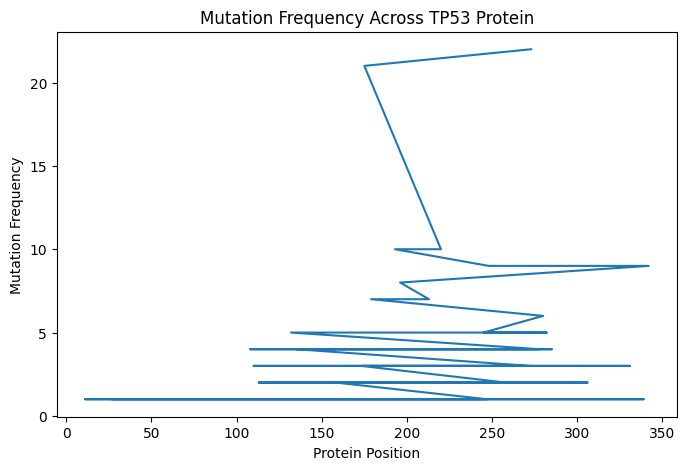


Validation Table:
   Known_driver_residue  Mutations_found
0                   175               21
1                   248                9
2                   273               22
3                   282                5


In [5]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("TP53_localized_mutations.csv")

df = df[df["Protein_Position"].notna()].copy()
df["Protein_Position"] = df["Protein_Position"].astype(int)
df["cDNA_Position"] = pd.to_numeric(df["cDNA_Position"], errors="coerce")

print("Total exonic mutations:", len(df))

# =====================================================
# LOAD CDS
# =====================================================

cds_record = SeqIO.read("TP53_cds_GRCh37.fasta", "fasta")
cds_seq = cds_record.seq

print("Protein length:", len(cds_seq)//3)

# =====================================================
# PART 1 — MUTATION TYPE CLASSIFICATION
# =====================================================

def classify_mutation(row):
    mut = str(row["Mutation"])
    prot_pos = int(row["Protein_Position"])
    cdna_pos = row["cDNA_Position"]

    if pd.isna(cdna_pos):
        return "Non-coding"

    # insertion/deletion
    if "-" in mut:
        ref, alt = mut.split(">")
        if len(ref) % 3 == 0 and len(alt) % 3 == 0:
            return "In-frame Indel"
        else:
            return "Frameshift"

    # SNP
    if ">" in mut and len(mut) == 3:
        ref_nt, alt_nt = mut.split(">")

        codon_index = prot_pos - 1
        codon_start = codon_index * 3

        if codon_start + 3 > len(cds_seq):
            return "Unknown"

        original_codon = cds_seq[codon_start:codon_start+3]
        original_aa = str(Seq(original_codon).translate())

        pos_in_codon = int(cdna_pos-1) % 3
        mutated_codon = list(str(original_codon))
        mutated_codon[pos_in_codon] = alt_nt
        mutated_codon = "".join(mutated_codon)

        mutated_aa = str(Seq(mutated_codon).translate())

        if mutated_aa == original_aa:
            return "Silent"
        elif mutated_aa == "*":
            return "Nonsense"
        else:
            return "Missense"

    return "Complex"

df["Mutation_Type"] = df.apply(classify_mutation, axis=1)

# -------- Mutation summary table -----
mut_summary = df["Mutation_Type"].value_counts().reset_index()
mut_summary.columns = ["Mutation_Type", "Count"]
mut_summary["Percentage"] = (mut_summary["Count"]/mut_summary["Count"].sum())*100

print("\nMutation Type Summary Table:")
print(mut_summary)

mut_summary.to_csv("Mutation_Type_Summary.csv", index=False)

# =====================================================
# PART 2 — DOMAIN DISTRIBUTION
# =====================================================

def map_domain(pos):
    if 1 <= pos <= 61:
        return "Transactivation"
    elif 102 <= pos <= 292:
        return "DNA_binding"
    elif 324 <= pos <= 355:
        return "Tetramerization"
    else:
        return "Other"

df["Domain"] = df["Protein_Position"].apply(map_domain)

domain_ranges = {
    "Transactivation": "1–61",
    "DNA_binding": "102–292",
    "Tetramerization": "324–355",
    "Other": "Rest"
}

domain_counts = df["Domain"].value_counts().to_dict()

domain_table = []
for d in domain_ranges:
    count = domain_counts.get(d,0)
    length = 0

    if d=="Transactivation": length=61
    elif d=="DNA_binding": length=191
    elif d=="Tetramerization": length=32
    else: length=393- (61+191+32)

    density = round(count/length,4)

    remark = "High clustering" if d=="DNA_binding" else ""

    domain_table.append([d, domain_ranges[d], count, density, remark])

domain_df = pd.DataFrame(domain_table,
                         columns=["Domain","Residue_Range","Num_Mutations","Density","Remarks"])

print("\nDomain-wise Mutation Table:")
print(domain_df)

domain_df.to_csv("Domain_Distribution.csv", index=False)

# =====================================================
# PART 3 — HOTSPOT DETECTION
# =====================================================

freq = df["Protein_Position"].value_counts()
top10 = freq.head(10)

print("\nTop 10 Hotspot Residues:")
print(top10)

top10.to_csv("Top10_hotspots.csv")

plt.figure(figsize=(8,5))
freq.plot(kind="line")
plt.title("Mutation Frequency Across TP53 Protein")
plt.xlabel("Protein Position")
plt.ylabel("Mutation Frequency")
plt.show()

# =====================================================
# PART 4 — VALIDATION TABLE
# =====================================================

known_hotspots = [175, 248, 273, 282]
validation_data = []

for pos in known_hotspots:
    count = df[df["Protein_Position"]==pos].shape[0]
    validation_data.append([pos,count])

validation_df = pd.DataFrame(validation_data,
                             columns=["Known_driver_residue","Mutations_found"])

print("\nValidation Table:")
print(validation_df)

validation_df.to_csv("Validation_hotspots.csv", index=False)

# =====================================================
# SAVE FINAL MASTER FILE
# =====================================================

df.to_csv("TP53_FINAL_COMPLETE.csv", index=False)